# Proyek Analisis Sentimen: Pembatasan Akses Sosmed & Game untuk Anak di Bawah 16 Tahun

**Proyek:** Analisis Sentimen Komentar YouTube (Kebijakan Medsos Anak < 16 Tahun)

**Alur notebook ini:**
1. Install & import library
2. Load dataset
3. Preprocessing teks
4. Pelabelan otomatis (InSet Lexicon)
5. Cek distribusi label
6. Simpan hasil

## Import Library

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud
import nltk

# Mengunduh model tokenizer (untuk memecah kata)
nltk.download('punkt_tab') # gunakan 'punkt' jika versi NLTK Anda versi lama
nltk.download('punkt') 

# Mengunduh daftar stopwords (untuk fungsi filtering Anda nanti)
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /Users/macbook-
[nltk_data]     airm2/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/macbook-
[nltk_data]     airm2/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/macbook-
[nltk_data]     airm2/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Exploratory Data Analysis (EDA)

### Load Dataset

In [2]:
# Load data
df = pd.read_csv('all_scraped_comments_final.csv')
df.sample(10)

,platform,video_id,video_title,author,comment,published_at,reply,like_comment
15649,YouTube,1YIiUl6rz9A,Serba-Serbi Fenomena Game Roblox: Anak-Anak Di...,@kinggame390supergaming,Roblox adalah game kesukaan anak2 gimana mau s...,2025-09-01T09:46:42Z,0,0
13543,YouTube,19eKDDkJt6w,"Komdigi Resmi Batasi Medsos, Akun di Bawah 16 ...",@AnitaFitriningsih,"I don't like this corrupt government, gambling...",2026-03-12T22:43:07Z,0,1
24240,YouTube,Ms5L_lkl9I8,Rahasia Apa yang Disimpan Media Sosial?,@azrielveteran2592,Aku cuma dipake buat liat meme,2021-09-17T23:43:06Z,0,1
8946,YouTube,TdyE62mSXx0,"Mulai Akhir Maret, Anak di Bawah 16 Tahun Tida...",@Miawkami,Siaplah anda akan di demo di yt sebelum 28 maret,2026-03-23T00:38:19Z,0,0
5219,YouTube Short,TdyE62mSXx0,"Mulai Akhir Maret, Anak di Bawah 16 Tahun Tida...",@Poppy_cute-i7z,...,2026-03-10T13:33:45Z,0,0
379,YouTube,p8p-sAq_hhI,Pemerintah Batasi Akun Medsos Anak di Bawah 16...,@ruruyakanruruyukanchanel5442,Judol dulu brantas,2026-03-08T14:30:20Z,0,0
6199,YouTube,R1hQwelEGvU,"Menkomdigi Resmi Batasi Medsos, Anak di Bawah ...",@mondyyacob420,Bu Mentri Judol berkeliaran dimana2 kenapa sam...,2026-03-06T12:51:15Z,20,5
15002,YouTube,viGBwFO3nDA,Komdigi blokir sosmed buat anak di bawah 16 ta...,@shizuku64bit,lucu sih ngeliat komentar ini dipenuhi bocah y...,2026-03-10T05:02:35Z,0,0
18643,YouTube,gvTzzvoWgho,CEK AKUN KALIAN ! TANGGAL 28 MARET AKUN DI BLO...,@jekk2805,Sbner nya mau bocil mau ga yng namnya drksiste...,2026-03-18T12:13:47Z,0,0
6644,YouTube,hzDavp3DQo4,"Komdigi: Mulai 28 Maret, Anak di Bawah 16 Tahu...",@VLN_VALINEツ,pemerintah gggggooooobbbbbllllloooookkkkk!,2026-03-27T15:45:40Z,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25899 entries, 0 to 25898
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   platform      25899 non-null  str  
 1   video_id      25899 non-null  str  
 2   video_title   25899 non-null  str  
 3   author        25899 non-null  str  
 4   comment       25899 non-null  str  
 5   published_at  25899 non-null  str  
 6   reply         25899 non-null  int64
 7   like_comment  25899 non-null  int64
dtypes: int64(2), str(6)
memory usage: 1.6 MB


### Cek Karakteristik Data

In [4]:
duplicate_count = df.duplicated(subset=['comment'], keep='first').sum()

null_count = (df['comment'].isnull() | (df['comment'].str.strip() == '')).sum()

print("Jumlah data duplikat:", duplicate_count)
print("Jumlah data null/kosong:", null_count)

print(f'Kolom          : {df.columns.tolist()}')
print(f'Missing values :\n{df.isnull().sum()}')
print()

df.info()
df['comment'].head(10)

Jumlah data duplikat: 3873
Jumlah data null/kosong: 0
Kolom          : ['platform', 'video_id', 'video_title', 'author', 'comment', 'published_at', 'reply', 'like_comment']
Missing values :
platform        0
video_id        0
video_title     0
author          0
comment         0
published_at    0
reply           0
like_comment    0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 25899 entries, 0 to 25898
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   platform      25899 non-null  str  
 1   video_id      25899 non-null  str  
 2   video_title   25899 non-null  str  
 3   author        25899 non-null  str  
 4   comment       25899 non-null  str  
 5   published_at  25899 non-null  str  
 6   reply         25899 non-null  int64
 7   like_comment  25899 non-null  int64
dtypes: int64(2), str(6)
memory usage: 1.6 MB


0    Jangan batasi akun saya banyak konten gta sama Hp
1    Masalah nya yang di pake hp orang tua nya\nGak...
2                             Bu mereka susah dipahami
3    Kenapa ga jelas kita bukan negara seperti erop...
4    ban semua medsos kecuali CHATGPT , kenapa aku ...
5                                         🤬🤬🤬🤬🤬🤬🤬🤬🤬🤬🤬🤬
6                                        😢😢😢😢😢😢😢😢😢😢😢😢😢
7    @Lui:1) zaman sekarang sudah penuh teknologi, ...
8                    𝗔𝗻𝗮𝗸 𝘀𝗲𝗸𝗮𝗿𝗮𝗻𝗴 𝗽𝗮𝗸𝗲 𝗵𝗽 𝘀𝗮𝘂𝗱𝗮𝗿𝗮𝗻𝘆𝗮😂
9                                            Anjingnya
Name: comment, dtype: str

### Cek judul Video Hasil Scrapping

In [5]:
unique_titles = df['video_title'].unique()

print(f"Total judul unik: {len(unique_titles)}")
unique_titles

Total judul unik: 69


<StringArray>
[     'Indonesia Batasi Penggunaan Medsos, Anak 13-16 Tahun Tak Lagi Bisa Bebas Akses Mulai Maret 2026',
                                                 'Pemerintah Batasi Akun Medsos Anak di Bawah 16 Tahun',
           'Menkomdigi Resmi Batasi Medsos, Anak di Bawah 16 Tahun Dilarang Miliki Akun Medsos | tvOne',
                               '[HEADLINE NEWS, 06/03] Penerapan Batasan Akses Media Sosial Untuk Anak',
                              'Pemerintah Larang Anak di Bawah 16 Tahun Akses Media Sosial #beritasatu',
                           'Komdigi: Mulai 28 Maret, Anak di Bawah 16 Tahun Dilarang Punya Akun Medsos',
                                 'Indonesia Batasi Medsos, Anak 13-16 Tahun Tak Bebas Akses Mulai 2026',
                  'Mulai Akhir Maret, Anak di Bawah 16 Tahun Tidak Boleh Lagi Akses Medsos dan Roblox!',
           'Pemerintah Resmikan Pembatasan Akses Digital Untuk Anak Dibawah Usia 16 Tahun | Kabar Pagi',
                                      'Pe

### Menampilkan Video tidak relevan berdasarkan judul

In [6]:
video_noise= [
    "Tutorial Cara PENGAJUAN UBAH UMUR DIBAWAH 13+ di ROBLOX 😍😍",
    "2 Cara Blokir Konten Dewasa Di Google",
    "iwan setiawan kecanduan game online",
    "Viral, Remaja 17 Tahun Gangguan Saraf Diduga Kecanduan Game Online, Tak Bisa Berhenti Bergerak",
    "BAHAYANYA HP bagi anak, kecanduan main hp ya gini⁉️#shortsfeed #shortsviral #fyp #beritaviral",
    "Modus Beri Tugas Like & Subscribe, Warga Depok Jadi Korban Penipuan Online Capai Puluhan Juta",
    "SOSIAL MEDIA PALING TOXIC❓",
    "Kacau! Wanita Ini Nekat Online 20 Jam Nonstop Main Game, Sampai Ditegur Oleh Sistem",
    "jangan suka mendengar headset! #shortsvideo",
    "Konten anak-anak bisa berdampak pelanggaran di facebook pro? #tempechannel #tutorialfacebook #fbpro",
    "Penipuan, pemerasan dan teror menggunakan modus VCS#penipuandigital #penipuanonline #edukasipenipuan",
    "KECANDUAN SOSMED",
    "Rahasia Apa yang Disimpan Media Sosial?",
    "Game JaDul yang udah di hapus dari PlayStore 😱!? #roblox#AvaThe3dDoll",
    "4 Jenis Konten Yang Tidak Bisa Dimonetisasi #shorts #youtubeshorts #edukasi #viral #diajarpinter",
    "Modus Beri Tugas Like &amp; Subscribe, Warga Depok Jadi Korban Penipuan Online Capai Puluhan Juta",
    "Penipuan, pemerasan dan teror menggunakan modus VCS#penipuandigital #penipuanonline #edukasipenipuan",
    "Game JaDul yang udah di hapus dari PlayStore 😱!? #roblox#AvaThe3dDoll",
    "Tutorial Cara PENGAJUAN UBAH UMUR DIBAWAH 13+ di ROBLOX 😍😍",
    "2 Cara Blokir Konten Dewasa Di Google",
    "cara aktifkan mode anak",
    "Tutorial cara memblokir aplikasi dan game diplaystore untuk anak dibawah umur",
    "Konten anak-anak bisa berdampak pelanggaran di facebook pro? #tempechannel #tutorialfacebook #fbpro",
    "SOSIAL MEDIA PALING TOXIC❓",
    "KECANDUAN SOSMED",
    "iwan setiawan kecanduan game online",
    "jangan suka mendengar headset! #shortsvideo",
    "Modus Beri Tugas Like &amp; Subscribe, Warga Depok Jadi Korban Penipuan Online Capai Puluhan Juta",
    "Wanita ini mencoba menipu penjual HP❗📱 #shorts #shortvideo",
    "Ciri Lowongan Kerja Palsu! #shorts #vinamuliana #tips #kerja",
    "4 Jenis Konten Yang Tidak Bisa Dimonetisasi #shorts #youtubeshorts #edukasi #viral #diajarpinter",
    "Konten anak-anak bisa berdampak pelanggaran di facebook pro? #tempechannel #tutorialfacebook #fbpro",
    "BERMAIN OLAH TUBUH, MELATIH MOTORIK KASAR ANAK TK",
    "cara aktifkan mode anak",
    "Tutorial Cara PENGAJUAN UBAH UMUR DIBAWAH 13+ di ROBLOX 😍😍",
    "2 Cara Blokir Konten Dewasa Di Google",
    "CARA BIAR AKUN ROBLOX AMAN DARI PEMERINTAH INDONESIA - TIPS & TRICK GAME ROBLOX",
    "BAHAYANYA HP bagi anak, kecanduan main hp ya gini⁉️#shortsfeed #shortsviral #fyp #beritaviral",
    "Tutorial cara memblokir aplikasi dan game diplaystore untuk anak dibawah umur",
    "ORANG TUA WAJIB TAHU! Kecanduan Game pada Anak Bisa Sebabkan Gangguan Jiwa | Kata Dokter",
    "Membahas Bahaya Game Roblox Terhadap Anak, Apa Solusinya? #Beritasatu",
    "Mantan Menkes Nila Moeloek Bahas Bahaya Game Online Bagi Anak [Metro Siang]",
    "Studi bilang anak main GAME lebih BAHAGIA daripada main SOSMED? #shorts",
    "iwan setiawan kecanduan game online",
    "Viral, Remaja 17 Tahun Gangguan Saraf Diduga Kecanduan Game Online, Tak Bisa Berhenti Bergerak",
    "SOSIAL MEDIA PALING TOXIC❓",
    "KECANDUAN SOSMED",
    "Rahasia Apa yang Disimpan Media Sosial?"
]


noise_df = df[df['video_title'].isin(video_noise)]

print(f"Jumlah data noise yang ditemukan: {len(noise_df)}")
if len(noise_df) > 0:
    # Mengambil sampel maksimal 10 (atau kurang dari 10 jika datanya sedikit)
    print("\nSampel data noise yang akan dihapus:")
    print(noise_df[['video_title', 'comment']].sample(min(10, len(noise_df))))



Jumlah data noise yang ditemukan: 6859

Sampel data noise yang akan dihapus:
                                             video_title  \
25844  4 Jenis Konten Yang Tidak Bisa Dimonetisasi #s...   
25801  4 Jenis Konten Yang Tidak Bisa Dimonetisasi #s...   
21686  Viral, Remaja 17 Tahun Gangguan Saraf Diduga K...   
24133            Rahasia Apa yang Disimpan Media Sosial?   
20180  Studi bilang anak main GAME lebih BAHAGIA dari...   
23379  Kacau! Wanita Ini Nekat Online 20 Jam Nonstop ...   
24733            Rahasia Apa yang Disimpan Media Sosial?   
24772            Rahasia Apa yang Disimpan Media Sosial?   
22503  Modus Beri Tugas Like &amp; Subscribe, Warga D...   
22099  Modus Beri Tugas Like &amp; Subscribe, Warga D...   

                                                 comment  
25844  Bang saya bikin video cerita dengan masukin be...  
25801                   Nyimak bang.. semoga cepet monet  
21686                               untung mak gw pinter  
24133                 gw y

## Preprocessing / Praproses Data

Pada tahap ini, beberapa proses pembersihan dan persiapan data dilakukan untuk memastikan kualitas dataset sebelum analisis sentimen. Berikut adalah langkah-langkah utama yang dijalankan:

1. **Delete Not Relevant Title**: Menghapus video berdasarkan judul yang tidak relevan dengan topik permasalahan (Kebijakan Pembatasan Sosial Media pada anak usia di bawah 16 tahun). Data ini diperoleh dari hasil scraping menggunakan keyword tertentu.

2. **Hapus Duplikat**: Menghilangkan komentar yang duplikat berdasarkan kolom 'comment' untuk menghindari bias dalam analisis.

3. **Hapus Data Kosong/Null**: Menghapus komentar yang kosong atau hanya berisi spasi, serta reset index dataframe.

4. **Hapus Noise (Emoji/Simbol Saja)**: Menghilangkan komentar yang hanya terdiri dari emoji atau simbol tanpa teks bermakna.

5. **Cleaning Teks**: Melakukan pembersihan teks meliputi:
    - Case folding (mengubah ke huruf kecil).
    - Menghapus emoji, URL, mention (@), hashtag (#), dan angka.
    - Menghapus tanda baca dan spasi berlebih.

6. **Fix Slang Words**: Mengganti kata-kata slang atau informal dengan bentuk standar menggunakan kamus slangwords.

7. **Filter Komentar Pendek**: Menghapus komentar yang terlalu pendek (kurang dari 3 kata) untuk memastikan komentar memiliki substansi.

8. **Delete Stopword**: Menghilangkan kata-kata stopword (kata hubung seperti "di", "ke", "dan") menggunakan library NLTK.

9. **Stemming**: Mengembalikan kata ke bentuk dasar menggunakan Sastrawi Stemmer.

10. **Final Data**: Menyimpan hasil akhir preprocessing ke kolom 'processed_comment' untuk siap digunakan dalam analisis selanjutnya.

### Delete Not Relevant Title

In [7]:
n = len(df)

df = df[~df['video_title'].isin(video_noise)]
df = df.reset_index(drop=True)

print(f'Dihapus (video tidak relevan): {n - len(df):,}')
print(f'Sisa data: {len(df):,}')



Dihapus (video tidak relevan): 6,859
Sisa data: 19,040


In [8]:
unique_titles = df['video_title'].unique()

print(f"Total judul unik: {len(unique_titles)}")
unique_titles

Total judul unik: 49


<StringArray>
[     'Indonesia Batasi Penggunaan Medsos, Anak 13-16 Tahun Tak Lagi Bisa Bebas Akses Mulai Maret 2026',
                                                 'Pemerintah Batasi Akun Medsos Anak di Bawah 16 Tahun',
           'Menkomdigi Resmi Batasi Medsos, Anak di Bawah 16 Tahun Dilarang Miliki Akun Medsos | tvOne',
                               '[HEADLINE NEWS, 06/03] Penerapan Batasan Akses Media Sosial Untuk Anak',
                              'Pemerintah Larang Anak di Bawah 16 Tahun Akses Media Sosial #beritasatu',
                           'Komdigi: Mulai 28 Maret, Anak di Bawah 16 Tahun Dilarang Punya Akun Medsos',
                                 'Indonesia Batasi Medsos, Anak 13-16 Tahun Tak Bebas Akses Mulai 2026',
                  'Mulai Akhir Maret, Anak di Bawah 16 Tahun Tidak Boleh Lagi Akses Medsos dan Roblox!',
           'Pemerintah Resmikan Pembatasan Akses Digital Untuk Anak Dibawah Usia 16 Tahun | Kabar Pagi',
                                      'Pe

### Hapus komentar duplicate

In [9]:
n = len(df)

df = df.drop_duplicates(subset=['comment'], keep='first')
df = df.dropna(subset=['comment'])
df = df[df['comment'].str.strip() != '']

df = df.reset_index(drop=True)

print(f'Dihapus: {n - len(df):,}')
print(f'Sisa data: {len(df):,}')

Dihapus: 3,700
Sisa data: 15,340


### hapus Noise / hapus komentar dengan emoji atau simbol saja

In [10]:
def is_noise_only(text):
    text = str(text)
    cleaned = re.sub(r'\d', '', re.sub(r'[^\w]', '', text))
    return len(cleaned.strip()) == 0

n = len(df)
df = df[~df['comment'].apply(is_noise_only)].reset_index(drop=True)

print(f'Noise dihapus: {n - len(df):,}')
print(f'Sisa data: {len(df):,}')

Noise dihapus: 242
Sisa data: 15,098


In [11]:
df['comment'].head(10)

0    Jangan batasi akun saya banyak konten gta sama Hp
1    Masalah nya yang di pake hp orang tua nya\nGak...
2                             Bu mereka susah dipahami
3    Kenapa ga jelas kita bukan negara seperti erop...
4    ban semua medsos kecuali CHATGPT , kenapa aku ...
5    @Lui:1) zaman sekarang sudah penuh teknologi, ...
6                    𝗔𝗻𝗮𝗸 𝘀𝗲𝗸𝗮𝗿𝗮𝗻𝗴 𝗽𝗮𝗸𝗲 𝗵𝗽 𝘀𝗮𝘂𝗱𝗮𝗿𝗮𝗻𝘆𝗮😂
7                                            Anjingnya
8    saran saya yak buk ya 😂 minimal judol juga dib...
9            Aku setuju dalam mimpi apakah saya setuju
Name: comment, dtype: str

### Cleaning Teks

In [12]:
import re
import unicodedata
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


factory = StemmerFactory()
stemmer = factory.create_stemmer()

def cleaningText(text):
  
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    
    # Menghapus mentions dan hashtags
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) 
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) 
    
    # Menghapus "RT"
    text = re.sub(r'\bRT\b', '', text) 
    
    # Menghapus link/URL
    text = re.sub(r"http\S+", '', text) 
    
    # 2. [SARAN 5] Mempertahankan Angka Relevan (seperti usia 16)
    # Saya matikan baris penghapus angka agar konteks "di bawah 16 tahun" tetap terjaga
    text = re.sub(r'[0-9]+', '', text) 
    
    # Menghapus simbol dan tanda baca, tapi tetap mempertahankan huruf dan angka (alfanumerik)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Merapikan spasi ganda dan baris baru
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text



def casefoldingText(text): 
    return text.lower()
    



### Fix Slang Words

In [13]:
slangwords = {
    "gue": "saya",
    "gua": "saya",
    "gw": "saya",
    "sy": "saya",
    "sya": "saya",
    "aq": "aku",
    "ku": "aku",
    "lu": "kamu",
    "lo": "kamu",
    "lw": "kamu",
    "elo": "kamu",
    "kau": "kamu",


    "gak": "tidak",
    "gk": "tidak",
    "ga": "tidak",
    "nggk":"tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "ngak": "tidak",
    "engga": "tidak",
    "enggak": "tidak",
    "kagak": "tidak",
    "kaga": "tidak",
    "ndak": "tidak",
    "tak": "tidak",
    "gabisa": "tidak bisa",
    "gaada": "tidak ada",
    "gpp": "tidak apa-apa",
    "pdhl":"padahal",
    "rblx":"roblox",
    "nyolong":"mencuri",


    "kalo": "kalau",
    "klo": "kalau",
    "kl": "kalau",
    "ama": "sama",
    "sm": "sama",
    "karna": "karena",
    "soalnya": "karena",


    "pake": "pakai",
    "liat": "lihat",
    "bikin": "membuat",
    "maen": "main",
    "nonton": "menonton",
    "ngurusin": "mengurus",
    "urusin": "urus",
    "diurusin": "diurus",
    "batasin": "batasi",
    "dilakuin": "dilakukan",
    "dibiarin": "dibiarkan",
    "biarin": "biarkan",
    "mainin": "mainkan",
    "nanya": "bertanya",
    "nyari": "mencari",
    "ngomong": "berbicara",
    "ngatur": "mengatur",
    "ngapain": "sedang apa",
    "ngasih": "memberikan",
    "nunggu": "menunggu",
    "ngerti": "mengerti",
    "ngebantu": "membantu",
    "ngonten": "membuat konten",

    "bener": "benar",
    "beneran": "sungguh",
    "gede": "besar",
    "seneng": "senang",
    "kesel": "kesal",
    "bosen": "bosan",
    "asik": "asyik",
    "males": "malas",
    "pinter": "pintar",
    "lagian": "lagipula",
    "palingan": "paling tidak",


    "udah": "sudah",
    "udh": "sudah",
    "sdh": "sudah",
    "ud": "sudah",
    "uda": "sudah",
    "dah": "sudah",
    "sampe": "sampai",
    "ampe": "sampai",
    "mpe": "sampai",
    "dlu": "dulu",
    "bentar": "sebentar",
    "ntar": "nanti",
    "tar": "nanti",
    "trus": "terus",
    "trs": "terus",
    "doang": "saja",
    "cuman": "hanya",
    "mending": "lebih baik",
    "mendingan": "lebih baik",
    "makin": "semakin",
    "masi": "masih",
    "jaman": "zaman",

    "nih": "ini",
    "ni": "ini",
    "tuh": "itu",
    "tu": "itu",
    "gitu": "begitu",
    "gini": "begini",
    "gtu": "begitu",
    "gimana": "bagaimana",
    "gmn": "bagaimana",
    "kayak": "seperti",
    "kek": "seperti",
    "kyk": "seperti",
    "ky": "seperti",
    "kayaknya": "sepertinya",
    "keknya": "sepertinya",

    
    "bang": "abang",
    "bng" : "abang",
    "bg": "abang",
    "kak": "kakak",
    "kk": "kakak",
    "bro": "teman",
    "buk": "ibu",
    "emak": "ibu",
    "nyokap": "ibu",
    "bokap": "ayah",
    "adek": "adik",
    "guys": "teman-teman",
    "min": "admin",


    "sih": "sih",
    "lah": "lah",
    "deh": "deh",
    "dong": "dong",
    "loh": "loh",
    "kok": "kok",
    "ko": "kok",
    "nah": "nah",
    "mah": "sih",
    "seru": "seru",

    "wah": "wah",
    "woi": "hei",
    "woy": "hei",
    "oi": "hei",
    "eh": "eh",
    "ah": "ah",
    "hah": "hah",
    "heh": "heh",
    "yah": "yah",
    "halah": "alah",
    "wkwk": "tertawa",
    "wkwkwk": "tertawa",
    "wkwkkw": "tertawa",
    "hehe": "tertawa",
    "haha": "tertawa",
    "lol": "tertawa",
    "bocil": "anak kecil",
    "bocah": "anak kecil",
    "gabut": "tidak ada kegiatan",
    "ortu": "orang tua",
    "pengen": "ingin",
    "kepengen": "ingin",
    "kepingin": "ingin",
    "tau": "tahu",
    "tw": "tahu",
    "emang": "memang",
    "emg": "memang",
    "ilang": "hilang",
    "tetep": "tetap",
    "bacot": "banyak bicara",
    "napa": "kenapa",
    "apaan": "apa",
    "apasih": "apa sih",


    "yg": "yang",
    "aja": "saja",
    "aj": "saja",
    "jg": "juga",
    "jgn": "jangan",
    "jd": "jadi",
    "jdi": "jadi",
    "tp": "tapi",
    "tpi": "tapi",
    "dr": "dari",
    "dri": "dari",
    "krn": "karena",
    "dgn": "dengan",
    "dpt": "dapat",
    "tdk": "tidak",
    "knp": "kenapa",
    "utk": "untuk",
    "bnyk": "banyak",
    "lg": "lagi",
    "bs": "bisa",
    "skrg": "sekarang",
    "jt": "juta",
    "dll": "dan lain-lain",
    "btw": "ngomong-ngomong",
    "pls": "tolong",
    "plis": "tolong",
    "pliss": "tolong",
    "fyi": "untuk informasi anda",
    "oot": "keluar dari topik",
    "sm": "sama",
    "sma": "sama",

    "th" : "tahun",   
    "ny" : "nya",   
    "pr" : "pekerjaan rumah",   
    "ps" : "playstation",   
    "tgl": "tanggal",  
    "tt" : "tiktok",   
    "iq" : "kecerdasan" ,   
    "mu" : "kamu",     
    "yuk" : "ayo",
 
    "judol": "judi online",
    "pinjol": "pinjaman online",
    "medsos": "media sosial",
    "sosmed": "media sosial",
    "hp": "ponsel",
    "mbbg":"mbg",
    "kondigi":"komdigi",
    "kemodigy":"komdigi",

    "wa": "whatsapp",
    "ig": "instagram",
    "fb": "facebook",
    "yt": "youtube",
    "yutub": "youtube",
    "yutube": "youtube",
    "vidio": "video",
    "hoaks": "berita bohong",
    "hoax": "berita bohong",
    

    # Game (Singkatan/Sebutan)
    # "ff": "free fire",
    # "ml": "mobile legends",
    # "pubg": "pubg",
    "epep": "ff",
    # "robux": "mata uang virtual roblox",


    "thx": "terima kasih",
    "makasih": "terima kasih",
    "sus": "mencurigakan",
    "game": "permainan",
    "gaming": "bermain permainan",
    "player": "pemain",
    "banned": "diblokir",
    "block": "blokir",
    "live": "siaran langsung",
    "channel": "saluran",
    "like": "suka",
    "upload": "unggah",
    "download": "unduh",
    
    "kids": "anak-anak",
    "top": "terbaik",
    "real": "nyata",
    "dark": "gelap",
    "stop": "berhenti",
    "play": "bermain",
    "login": "masuk",
    "social": "sosial",
    "online": "daring",
    "platform": "platform",
    "chat": "mengobrol",
    "update": "perbarui",
    "mobile": "ponsel",
    "ai": "kecerdasan buatan",
    "subscribe": "berlangganan",
    "subscriber": "pelanggan",
    # "you": "kamu",
    # "and": "dan",
    # "the": "(kata sandang Inggris)",
    # "is": "adalah",
    # "in": "di dalam",
    # "to": "untuk",
    # "of": "dari",
    # "we": "kami",
    # "be": "menjadi",
    # "it": "itu",
    # "no": "tidak",
    "please": "tolong",
    "toxic": "merusak",
    "stress": "stres",
    "legend": "legenda",
    "legends": "legenda-legenda",
    "jlk":"jelek",
    
    "anjir": "anjing",
    "anjjan": "anjing",
    "anj": "anjing",
    "njir": "anjing",
    "jir": "anjing",
    "cok": "jancuk",
    "goblok": "bodoh",
    "tolol": "bodoh",
    "bego": "bodoh",
    "bacot": "banyak bicara",
    "tai": "tahi",

    "anak2": "anak-anak",
    "ank": "anak",
    "adek": "adik",
    "mbak": "kakak perempuan",
    "ko": "kok",
    "disini": "di sini",
    "dibawah": "di bawah",
    "diatas": "di atas",
    "dimana": "di mana",
    "dikit": "sedikit",
    "duit": "uang",
     "yak": "ya", "simpen": "menyimpan", "@": "di", "abis": "habis", "wtb": "beli",
    "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal",
    "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget",
    "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber",
    "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha",
    "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku",
    "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur",
    "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial",
    "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik",
    "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis",
    "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang",
    "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget",
    "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda",
    "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar",
    "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang",
    "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental",
    "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan",
    "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah",
    "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat",
    "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru",
    "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia",
    "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat",
    "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar",
    "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal",
    "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang",
    "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep",
    "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci",
    "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek",
    "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor",
    "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh",
    "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan",
    "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana",
    "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan",
    "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana",
    "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian",
    "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya",
    "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile",
    "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang",
    "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi",
    "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka",
    "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila",
    "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana",
    "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda",
    "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya",
    "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan",
    "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "berita bohong",
    "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah",
    "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut",
    "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image",
    "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing",
    "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke",
    "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak",
    "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu",
    "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan",
    "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional",
    "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau",
    "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima",
    "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian",
    "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin",
    "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet",
    "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan",
    "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan",
    "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara",
    "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat",
    "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan",
    "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa",
    "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu",
    "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih",
    "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa",
    "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan",
    "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol",
    "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa",
    "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar",
    "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak",
    "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya",
    "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif",
    "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak",
    "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta",
    "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan",
    "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel",
    "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah",
    "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau",
    "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari",
    "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton",
    "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk",
    "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos",
    "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic",
    "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan",
    "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik",
    "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional",
    "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani",
    "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi",
    "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling",
    "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi",
    "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman",
    "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi",
    "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia",
    "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus",
    "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa",
    "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya",
    "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip",
    "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat",
    "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik",
    "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit",
    "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat",
    "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf",
    "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti",
    "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit",
    "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi",
    "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman",
    "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih",
    "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon",
    "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat",
    "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi",
    "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama",
    "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu",
    "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu",
    "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing",
    "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi",
    "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa",
    "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain",
    "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord",
    "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja",
    "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja",
    "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa",
    "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik",
    "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu",
    "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara",
    "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden",
    "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena",
    "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua",
    "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget",
    "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau",
    "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci",
    "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar",
    "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali",
    "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok",
    "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap",
    "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep",
    "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang",
    "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan",
    "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali",
    "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa",
    "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis",
    "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh",
    "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil",
    "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah",
    "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh",
    "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali",
    "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah",
    "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi",
    "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji",
    "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian",
    "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban",
    "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang",
    "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar",
    "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan",
    "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan",
    "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian",
    "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus",
    "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok",
    "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing",
    "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti",
    "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan",
    "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat",
    "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta",
    "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu",
    "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram",
    "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan",
    "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus",
    "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras",
    "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede",
    "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing",
    "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa",
    "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis",
    "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri",
    "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon",
    "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus",
    "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan",
    "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar",
    "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak",
    "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu",
    "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari",
    "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok",
    "gituuuuuu": "gitu", "gk": "tidak",
    "ga": "tidak", "gk": "tidak", "nggak": "tidak", "bocil": "anak kecil", "judol": "judi online",
    "omon": "omong kosong", "omon-omon": "omong kosong", "woi": "hei", "woy": "hei",
    "konoha": "pemerintah", "medsos": "media sosial", "sosmed": "media sosial",
    "blokir": "dilarang", "diblokir": "dilarang", "demo": "demonstrasi",
    "hoax": "berita bohong", "pake": "pakai", "gimana": "bagaimana", "aja": "saja",
    "yg": "yang", "gw": "saya", "gua": "saya", "lu": "kamu", "udah": "sudah",
    "tau": "tahu", "kok": "kenapa", "tuh": "itu", "lah": "lah", "sih": "sih", "dah" : "sudah","ngajak":"mengajak","gara²":"gara-gara", "anak²": "anak-anak", "hujatanhujatan":"hujatan","yaa":"ya",
    "g": "tidak",
    "utk": "untuk",
    "cuma": "hanya",
    "mantab":"mantap",
    "mntap":"mantap",
    "ngepekk":"berpengaruh",
    "ngepek":"berpengaruh",
    "otaaak":"otak",
    "segala gala":"segalanya",
    "ggak":"tidak",
    "kbanyakan":"kebanyakan",
    "josjis":"mantap",
    "setujuhhhhhhhhhhhhhhh":"setuju",
    "telatt":"terlambat",
    "setujuuuuu":"setuju",
    "denger":"dengar",
    "gakkkkkkkk":"tidak",
    "yaallah":"ya tuhan",
    "ngebatesin":"membatasi",
    "tol":"bodoh",
    "bocilny":"anak kecilnya",
    "bussid":"omong doang",
    "blo on":"bodoh",
    "okeee":"iya",
    "anakn":"anak",
    "hoaxxxx":"berita bohong",
    "kerjaanbyg":"kerjaannya",
    "ingetttt":"ingat",
    "tolo":"bodoh",
    "b":"biasa",
    "howak":"berita bohong",
    "jangang":"jangan",
    "kgk":"tidak",
    "iso":"bisa",
    "hoaxxx":"berita bohong",
    "ges":"teman-teman",
    "yapping":"banyak omong",
    "bohongggggg":"bohong",
    "omong2":"ngomong doang",
    "monyet":"monyet",
    "atiran":"aturan",
    "org":"orang",
    "menkomdigi":"komdigi",
    "nihhh":"ini",
    "apk":"aplikasi",
    "gem":"permainan",
    "bgmna":"bagaimana",
    "asuk":"anjing",
    "anjink":"anjing",
    "nooo":"tidak",
    "nyocot":"banyak omong",
    "hoaxxxxxxxxxcxxx":"berita bohong",
    "boong":"bohong",
    "whyyy":"mengapa",
    "noooo":"tidak",
    "bae":"benar",
    "gelut":"berkelahi",
    "cet":"kirim pesan",
    "asyik":"asik",
    "sono":"sana",
    "kenaaaaaaaapaaaaaaaaa":"kenapa",
    "batasiiiiiiiiiiiiiiiiiiiiiiiiiiiiiih":"dibatasi",
    "gggggooooobbbbbllllloooookkkkk":"bodoh",
    "asv":"anjing",
    "scam":"penipuan",
    "keadilaaannnn":"keadilan",
    "palsuin":"palsukan",
    "ojo":"cukup",
    "dawg":"sobat",
    "meding":"mending",
    "jng":"jangan",
    "gakkkkkkkk":"tidak",
    "pilsss":"tolong",
    "y":"iya",
    "hilangin":"hilangkan",
    "ngk":"tidak",
    "terb0d0h":"terbodoh",
    "setuju2":"setuju",
    "veri":"sangat",
    "gud":"bagus",
    "kpan":"kapan",
    "undang2":"undang-undang",
    "emag":"memang",
    "pertanyaan2":"pertanyaan-pertanyaan",
    "apasi":"apa sih",
    "jud0l":" judi online",
    "brainrot": "sulit fokus",
    "gakkk":"tidak",
    "hoaxx":"berita bohong",
    "gakkkkkkkkkkkkkkkkk":"tidak", 
    "robloxxxxxxxxxxxxxxxxxxxxxxxx":"roblox",
    "hpp":"ponsel",
    "deket":"dekat",
    "taaaaiiiiii":"tahi",
    "ngluh":"mengeluh",
    "roblix":"roblox",
    "gamau":"tidak mau",
    "biar":"supaya",
    "jangannnnnnnnnnnnnnnnnnnnn":"jangan",
    "hapusssssss":"hapus",
    "gakkk":"tidak",
    "iniiiiiii":"ini",
    "kalow":"kalau",
    "sapa":"siapa",
    "donggggg":"dong",
    "bocil2":"anak kecil",
    "setujuuuuuuuuuuuuuuuuuuuu":"setuju",
    "hoaaaaaaaaaaax":"berita bohong",
     "gak": "tidak",
    "g": "tidak",
    "utk": "untuk",
    "cuma": "hanya",
    "tetapi":"tapi",
    "haru":"harus"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [14]:
from locale import normalize
def tokenizing(text):
    return word_tokenize(text)

def filtering(text):
    
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    
    listStopwords.update(['yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan', 'ke', 'dalam', 'ini', 'itu',
    'ada', 'adalah', 'sebagai', 'oleh', 'tidak', 'akan', 'bisa', 'sudah', 'saya', 'kamu',
    'dia', 'kami', 'mereka', 'kita', 'juga', 'atau', 'tetapi', 'karena', 'kalau', 'sama',
    'lebih', 'banyak', 'sedikit', 'baru', 'lama', 'masih', 'belum', 'lagi', 'hanya', 'saja',
    'pernah', 'sekarang', 'nanti', 'begitu', 'seperti', 'sehingga', 'sangat', 'terlalu',
    'nah', 'ya', 'deh', 'dong', 'lah', 'nih', 'tu', 'kan', 'kok', 'si', 'kah','hah','loh','nya','ah','oh'])
    
    
    kata_penting = [
        'tidak', 'bukan', 'jangan', 'belum', 'kurang', 
        'tapi', 'namun', 'walaupun', 'meskipun',       
        'bisa', 'mau', 'harus', 'boleh', 'dapat'        
    ]
    
    for kata in kata_penting:
        listStopwords.discard(kata)

    filtered = [txt for txt in text if txt not in listStopwords]
    return filtered

def stemming(text):
    return stemmer.stem(text)

def toSentence(list_words):
    return ' '.join(word for word in list_words)






In [15]:
df['comment_clean']= df['comment'].apply(cleaningText)

df['comment_casefold']= df['comment_clean'].apply(casefoldingText)

df['comment_fixslang']= df['comment_casefold'].apply(fix_slangwords)

df['comment_tokenized']= df['comment_fixslang'].apply(tokenizing)

df['comment_stopword']= df['comment_tokenized'].apply(filtering)



df['final_comment']= df['comment_stopword'].apply(toSentence)

df['comment_stemming']= df['final_comment'].apply(stemming)
# df['final_comment']= df['final_comment'].apply(stemming)

print(df[['comment_clean', 'final_comment']].head())


                                       comment_clean  \
0  Jangan batasi akun saya banyak konten gta sama Hp   
1  Masalah nya yang di pake hp orang tua nya Gak ...   
2                           Bu mereka susah dipahami   
3  Kenapa ga jelas kita bukan negara seperti erop...   
4  ban semua medsos kecuali CHATGPT kenapa aku pe...   

                                       final_comment  
0               jangan batasi akun konten gta ponsel  
1  pakai ponsel orang tua tidak berpengaruh sebat...  
2                                  bu susah dipahami  
3                           tidak bukan negara eropa  
4  ban media sosial kecuali chatgpt diban dibatas...  


In [16]:
# Menyimpan dataframe ke dalam file CSV baru
df.to_csv('hasil_preprocessing_komentar.csv', index=False, encoding='utf-8')

print("Data berhasil disimpan ke 'hasil_preprocessing_komentar.csv'")

Data berhasil disimpan ke 'hasil_preprocessing_komentar.csv'


## Anotasi Data (Pelabelan)

In [17]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [18]:
def sentiment_analysis_lexicon_indonesia(text):
    # Inisialisasi skor sentimen
    score = 0

    # text adalah LIST OF TOKENS (dari comment_stopword)
    for word in text:
        # Lewati kata terlalu pendek (noise)
        if len(word) <= 1:
            continue

        # Prioritaskan lexicon positif
        if word in lexicon_positive and word not in lexicon_negative:
            score += lexicon_positive[word]
        # Lexicon negatif (yang TIDAK juga ada di positif)
        elif word in lexicon_negative and word not in lexicon_positive:
            score += lexicon_negative[word]
        # Kata ada di keduanya: ambil yang absolutnya lebih besar
        elif word in lexicon_positive and word in lexicon_negative:
            pos_val = lexicon_positive[word]
            neg_val = lexicon_negative[word]
            if abs(pos_val) >= abs(neg_val):
                score += pos_val
            else:
                score += neg_val

    # Penentuan polaritas
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [19]:
results = df['comment_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]
print(df['polarity'].value_counts())

polarity
negative    9358
positive    2974
neutral     2766
Name: count, dtype: int64


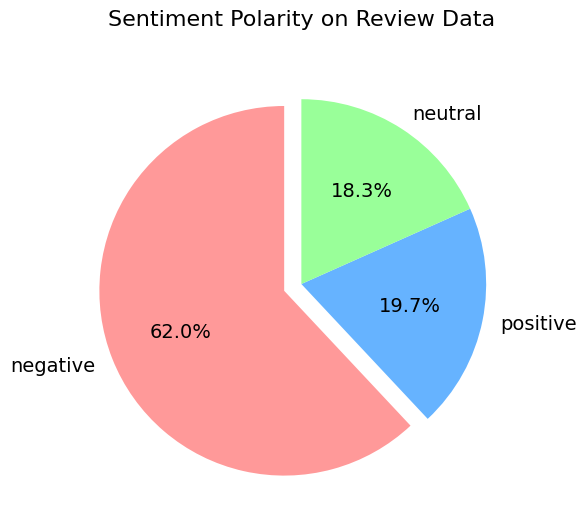

In [20]:
import matplotlib.pyplot as plt

# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci.
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data dan label dari DataFrame secara langsung
sentiment_counts = df['polarity'].value_counts()
sizes = sentiment_counts.values
labels = sentiment_counts.index

# PERBAIKAN PENTING: Membuat tuple explode secara dinamis.
# Ini akan memberikan nilai 0.1 untuk kategori terbanyak (pertama), dan 0 untuk sisanya.
# Sehingga, berapapun jumlah kelasnya (2 atau 3), tidak akan terjadi error.
explode = tuple([0.1 if i == 0 else 0 for i in range(len(labels))])

# (Opsional) Menentukan warna agar sesuai dengan sentimen
color_map = {
    'positive': '#66b3ff',  # Biru muda
    'negative': '#ff9999',  # Merah muda
    'neutral': '#99ff99'    # Hijau muda
}
# Mengambil daftar warna sesuai label yang ada
colors = [color_map.get(label, '#cccccc') for label in labels]

# Membuat pie chart dengan data yang telah disesuaikan
ax.pie(
    x=sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    explode=explode, 
    colors=colors,        # Menambahkan warna
    textprops={'fontsize': 14},
    startangle=90,        # Membuat chart dimulai dari sudut tegak lurus (opsional agar lebih rapi)        # Menambahkan efek bayangan (opsional)
)

# Menetapkan judul untuk pie chart
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

In [21]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_comments' yang hanya berisi comment dengan polaritas positif.
positive_comments = df[df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_comments'.
positive_comments = positive_comments[['final_comment', 'polarity_score', 'polarity','comment_stopword']]

# Mengurutkan DataFrame 'positive_comments' berdasarkan 'polarity_score' secara menurun.
positive_comments = positive_comments.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_comments = positive_comments.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_comments.index += 1

In [22]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_comments' yang hanya berisi comment dengan polaritas negatif.
negative_comments = df[df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_comments'.
negative_comments = negative_comments[['final_comment', 'polarity_score', 'polarity','comment_stopword']]

# Mengurutkan DataFrame 'negative_comments' berdasarkan 'polarity_score' secara menaik (ascending).
negative_comments = negative_comments.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_comments = negative_comments[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_comments = negative_comments.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_comments.index += 1

In [23]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'neutral_comments' yang hanya berisi comment dengan polaritas netral.
neutral_comments = df[df['polarity'] == 'neutral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'neutral_comments'.
neutral_comments = neutral_comments[['final_comment', 'polarity_score', 'polarity','comment_stopword']]

# Mengurutkan DataFrame 'neutral_comments' berdasarkan 'polarity_score' secara menurun.
neutral_comments = neutral_comments.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
neutral_comments = neutral_comments.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame agar tampilan dimulai dari angka 1.
neutral_comments.index += 1

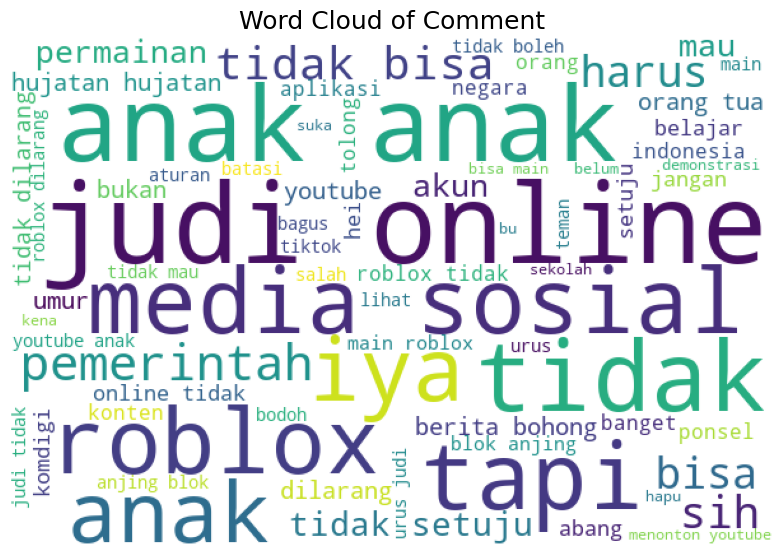

In [24]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan.
list_words = ''

# Iterasi melalui setiap comment dalam kolom 'text_stopword' dari DataFrame 'clean_df'.
for comment in df['comment_stopword']:
    # Iterasi melalui setiap kata dalam comment.
    for word in comment:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Comment', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

### Menampilkan Word Cloud of Negative Comment

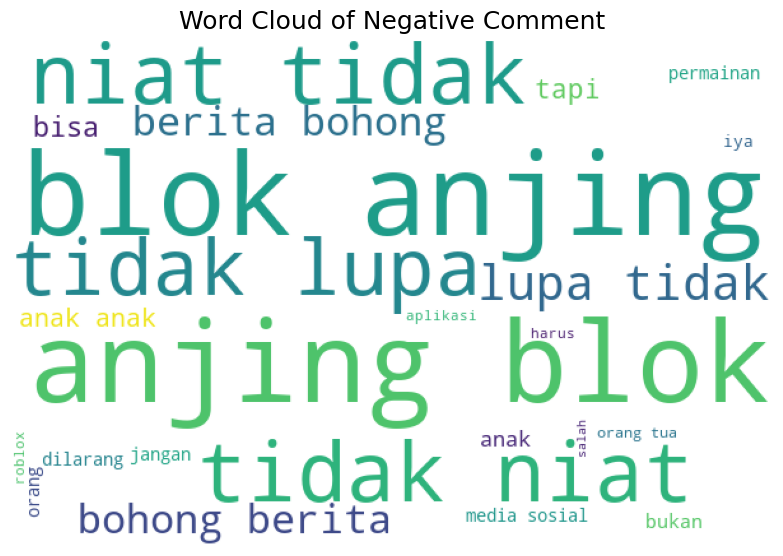

In [25]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam comment negatif.
list_words = ''

# Iterasi melalui setiap comment dalam kolom 'text_stopword' dari DataFrame 'negative_comments'.
for comment in negative_comments['comment_stopword']:
    # Iterasi melalui setiap kata dalam comment.
    for word in comment:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Comment', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

### Menampilkan Word Cloud of Positive Comment

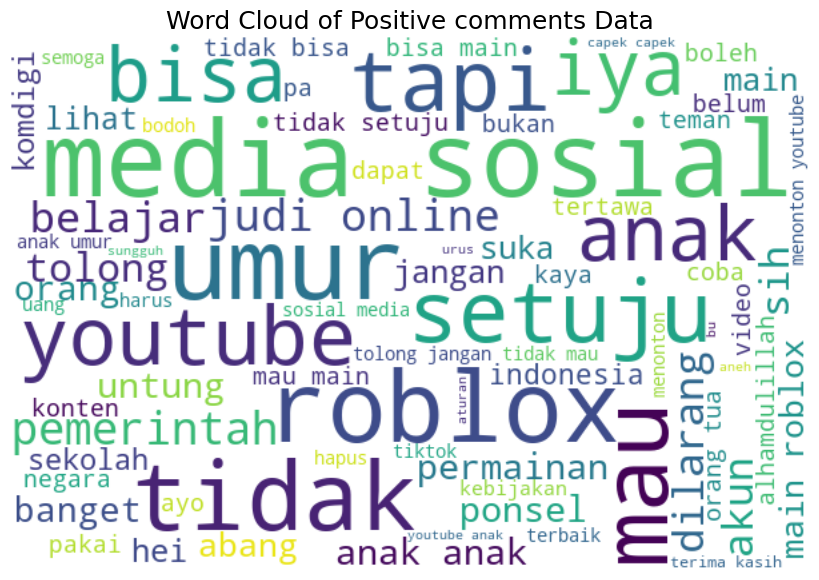

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Menggabungkan semua kata dengan jauh lebih efisien menggunakan list comprehension dan .join()
# Asumsi: setiap entri di 'comment_stopword' adalah list berisi kata-kata (string)
all_words = ' '.join([' '.join(comment) for comment in positive_comments['comment_stopword']])

# 2. Membuat objek WordCloud dengan parameter tertentu
wordcloud = WordCloud(
    width=600, 
    height=400, 
    background_color='white', 
    min_font_size=10
).generate(all_words)

# 3. Membuat gambar dan sumbu untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul
ax.set_title('Word Cloud of Positive comments Data', fontsize=18)

# Menampilkan word cloud (ditambah interpolasi agar lebih halus)
ax.imshow(wordcloud, interpolation='bilinear')

# Menyembunyikan sumbu (secara otomatis mematikan grid juga)
ax.axis('off')

# Mengatur layout gambar
fig.tight_layout(pad=0)

# Menampilkan word cloud
plt.show()

### Menampilkan Word Cloud of Neutral Comment

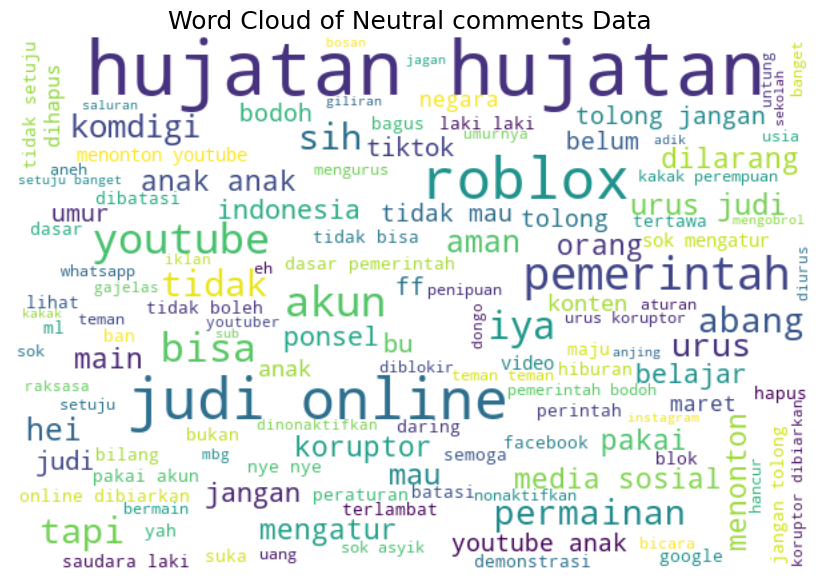

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Menggabungkan semua kata dengan jauh lebih efisien menggunakan list comprehension dan .join()
# Asumsi: setiap entri di 'comment_stopword' adalah list berisi kata-kata (string)
all_words = ' '.join([' '.join(comment) for comment in neutral_comments['comment_stopword']])

# 2. Membuat objek WordCloud dengan parameter tertentu
wordcloud = WordCloud(
    width=600, 
    height=400, 
    background_color='white', 
    min_font_size=10
).generate(all_words)

# 3. Membuat gambar dan sumbu untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul
ax.set_title('Word Cloud of Neutral comments Data', fontsize=18)

# Menampilkan word cloud (ditambah interpolasi agar lebih halus)
ax.imshow(wordcloud, interpolation='bilinear')

# Menyembunyikan sumbu (secara otomatis mematikan grid juga)
ax.axis('off')

# Mengatur layout gambar
fig.tight_layout(pad=0)

# Menampilkan word cloud
plt.show()

### Visualisasi Persebaran Sentimen 

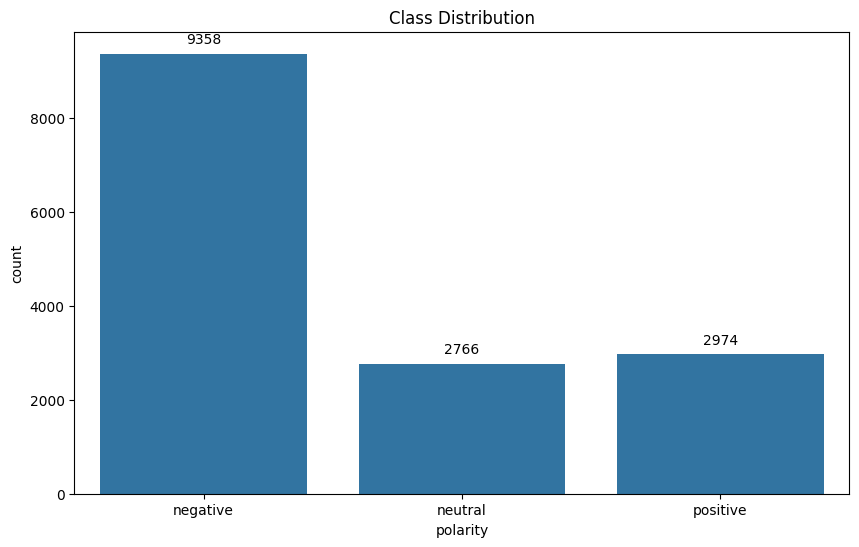

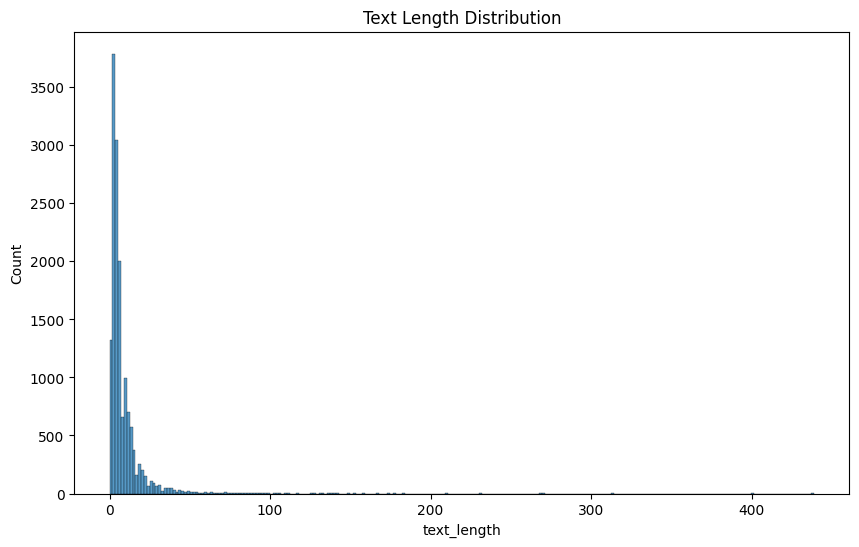

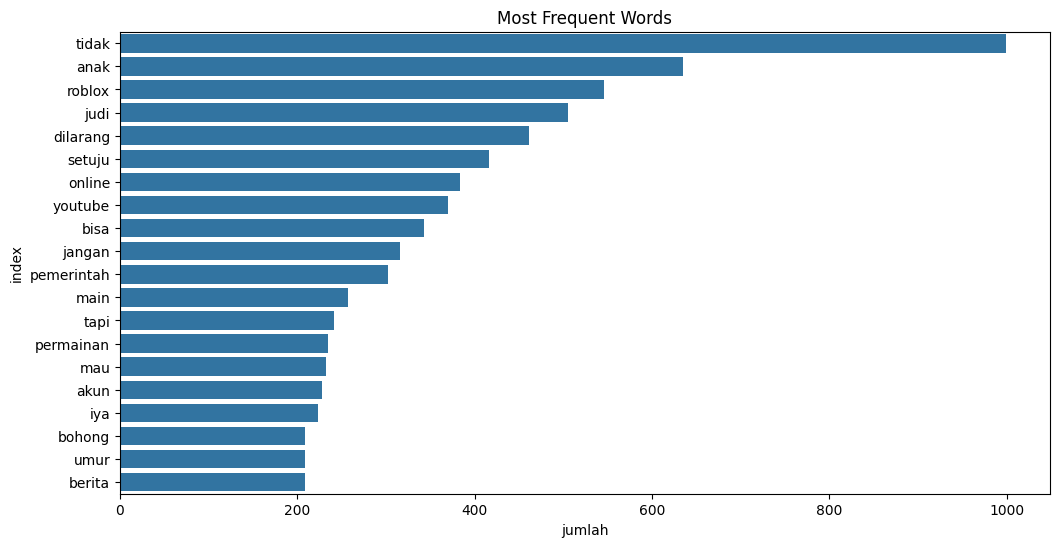

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
df['text_length'] = df['final_comment'].apply(lambda x: len(x.split()))
sns.histplot(df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X_viz = vectorizer.fit_transform(df['final_comment'])
tfidf_df = pd.DataFrame(X_viz.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

## Modelling

In [29]:
# Pisahkan data menjadi fitur (comment) dan label (sentimen)
X = df['final_comment']
y = df['polarity']

### Skenario 1
Pelatihan: SVM,    
Ekstraksi Fitur: TF-IDF,    
Pembagian Data: 80/20


Modeling SVM

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Ekstraksi fitur menggunakan TF-IDF
tfidf_svm = TfidfVectorizer(
    max_features=1000,      # Mengambil 5000 kata/frasa terpenting (naik dari 200)
    min_df=5,               # Kata minimal harus muncul di 5 baris comment agar tidak dibuang
    max_df=0.8,             # Mengabaikan kata yang muncul di lebih dari 80% data
    # ngram_range=(1, 2) ,     # Membaca kombinasi 1 kata tunggal dan 2 kata berdampingan
    # sublinear_tf=True       # Parameter baru: Mencegah dominasi kata yang diulang-ulang
)
X_tfidf_svm = tfidf_svm.fit_transform(X)


# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf_svm.toarray(), columns=tfidf_svm.get_feature_names_out())

# Split data menjadi training dan testing set
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_tfidf_svm, y, test_size=0.2, random_state=42)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score # Asumsi Anda menggunakan ini untuk metrik

# Membuat objek model SVM
# kernel='linear' sangat direkomendasikan untuk data teks/NLP
svm_model = SVC(kernel='linear', C=3, class_weight='balanced', random_state=42)
# Melatih model SVM pada data pelatihan
# Catatan: SVM mendukung matriks sparse (sparse matrix), 
# jika Anda kehabisan memori (RAM), coba hapus '.toarray()'
svm_model.fit(X_train_svm.toarray(), y_train_svm)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm_model.predict(X_train_svm.toarray())
y_pred_test_svm = svm_model.predict(X_test_svm.toarray())

# Evaluasi akurasi model SVM
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train_svm)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test_svm)

# Menampilkan akurasi dalam bentuk persentase
print(f"SVM - accuracy_train: {accuracy_train_svm * 100:.2f}%")
print(f"SVM - accuracy_test: {accuracy_test_svm * 100:.2f}%")



SVM - accuracy_train: 92.48%
SVM - accuracy_test: 88.41%


### Skenario 2
Pelatihan: RF,    
Ekstraksi Fitur: Word2Vec,    
Pembagian Data: 80/20


In [45]:

import numpy as np
import gensim
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


X_vec = df['final_comment']
y_vec = df['polarity']

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y_vec,
    test_size=0.2,
    random_state=42,
    stratify=y_vec
)

# Tokenisasi sederhana
tokenized_train = [str(text).split() for text in X_train]
tokenized_test  = [str(text).split() for text in X_test]

# ============================================================
# 2. WORD2VEC (OPTIMAL)
# ============================================================
w2v_model = gensim.models.Word2Vec(
    sentences=tokenized_train,

    vector_size=1000,   
    window=50,          
    min_count=2,       
    workers=4,
    epochs=50,         
    sg=1,              
    # negative=10
)


def get_sentence_vector(words, model):
    vectors = []
    
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size * 4)
    
    vectors = np.array(vectors)
    
    mean_vec = np.mean(vectors, axis=0)
    max_vec  = np.max(vectors, axis=0)
    std_vec  = np.std(vectors, axis=0)
    min_vec  = np.min(vectors, axis=0)
    
    return np.concatenate([mean_vec, max_vec, std_vec, min_vec])

X_train_vec = np.array([get_sentence_vector(words, w2v_model) for words in tokenized_train])
X_test_vec  = np.array([get_sentence_vector(words, w2v_model) for words in tokenized_test])



rf_model = RandomForestClassifier(
    n_estimators=1000,        
    max_depth=100,            
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_vec, y_train)


y_pred_train = rf_model.predict(X_train_vec)
y_pred_test  = rf_model.predict(X_test_vec)

accuracy_train_rf2 = accuracy_score(y_train, y_pred_train)
accuracy_test_rf2  = accuracy_score(y_test, y_pred_test)

print("\n=== FINAL RF + WORD2VEC ===")
print(f"Accuracy Train : {accuracy_train_rf2 * 100:.2f}%")
print(f"Accuracy Test  : {accuracy_test_rf2 * 100:.2f}%")




Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



=== FINAL RF + WORD2VEC ===
Accuracy Train : 99.27%
Accuracy Test  : 82.45%


### Skenario 3
Pelatihan: RF,    
Ekstraksi Fitur: WorTF-IDF,    
Pembagian Data: 70/30


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


print("Ekstraksi fitur TF-IDF...")
tfidf_rf3 = TfidfVectorizer(
    max_features=1000,      
    min_df=3,               
    max_df=0.70,            
    sublinear_tf=True,      
    analyzer='word'
)
X_tfidf_rf3 = tfidf_rf3.fit_transform(X)


X_train_rf3, X_test_rf3, y_train_rf3, y_test_rf3 = train_test_split(X_tfidf_rf3, y, test_size=0.3, random_state=42)


print("Mulai melatih model Random Forest...")
random_forest = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

random_forest.fit(X_train_rf3.toarray(), y_train_rf3)

y_pred_train_rf3 = random_forest.predict(X_train_rf3.toarray())
y_pred_test_rf3 = random_forest.predict(X_test_rf3.toarray())

accuracy_train_rf3 = accuracy_score(y_pred_train_rf3, y_train_rf3)
accuracy_test_rf3 = accuracy_score(y_pred_test_rf3, y_test_rf3)

print(f'Skenario 3 (RF + TF-IDF) - accuracy_train: {accuracy_train_rf3 * 100:.2f}%')
print(f'Skenario 3 (RF + TF-IDF) - accuracy_test: {accuracy_test_rf3 * 100:.2f}%')

Ekstraksi fitur TF-IDF...
Mulai melatih model Random Forest...
Skenario 3 (RF + TF-IDF) - accuracy_train: 97.47%
Skenario 3 (RF + TF-IDF) - accuracy_test: 86.82%


## Evaluasi Model

In [34]:
import pandas as pd

# Mengumpulkan data dari variabel yang sudah dihasilkan di tiap skenario
data_rangkuman = {
    'Skenario': [
        'Skenario 1', 
        'Skenario 2', 
        'Skenario 3'
    ],
    'Model': [
        'SVM', 
        'Random Forest', 
        'Random Forest'
    ],
    'Ekstraksi Fitur': [
        'TF-IDF', 
        'Word2Vec', 
        'TF-IDF'
    ],
    'Rasio Split Data': [
        '80 : 20', 
        '80 : 20', 
        '70 : 30'
    ],
    # Mengalikan dengan 100 agar menjadi format persentase yang mudah dibaca
    'Akurasi Training (%)': [
        round(accuracy_train_svm * 100, 2),
        round(accuracy_train_rf2 * 100, 2),
        round(accuracy_train_rf3 * 100, 2)
    ],
    'Akurasi Testing (%)': [
        round(accuracy_test_svm * 100, 2),
        round(accuracy_test_rf2 * 100, 2),
        round(accuracy_test_rf3 * 100, 2)
    ]
}

# Membuat DataFrame
df_rangkuman = pd.DataFrame(data_rangkuman)

# Menampilkan tabel
print("=== Rangkuman Akurasi Keseluruhan Model ===")
display(df_rangkuman)

=== Rangkuman Akurasi Keseluruhan Model ===


,Skenario,Model,Ekstraksi Fitur,Rasio Split Data,Akurasi Training (%),Akurasi Testing (%)
0,Skenario 1,SVM,TF-IDF,80 : 20,92.48,88.41
1,Skenario 2,Random Forest,Word2Vec,80 : 20,98.63,82.38
2,Skenario 3,Random Forest,TF-IDF,70 : 30,97.47,86.82


## Predikisi Data Baru

In [ ]:
import numpy as np


kalimat_baru = input("Masukkan kalimat baru: ")

kalimat_baru_cleaned = cleaningText(kalimat_baru)
kalimat_baru_casefolded = casefoldingText(kalimat_baru_cleaned)
kalimat_baru_slangfixed = fix_slangwords(kalimat_baru_casefolded)
kalimat_baru_tokenized = tokenizing(kalimat_baru_slangfixed)
kalimat_baru_filtered = filtering(kalimat_baru_tokenized)
kalimat_baru_final = toSentence(kalimat_baru_filtered)

print("\nKalimat asli:", kalimat_baru)
print("-" * 50)
print("HASIL PREDIKSI DARI KETIGA MODEL")
print("-" * 50)

# Prediksi dengan Skenario 1 (SVM + TF-IDF)

X_kalimat_svm = tfidf_svm.transform([kalimat_baru_final])
X_kalimat_svm = tfidf_svm.transform([kalimat_baru_final]).toarray()

prediksi_svm = svm_model.predict(X_kalimat_svm)[0]
print(f"Skenario 1 (SVM + TF-IDF)       : {prediksi_svm.upper()}")



# Prediksi dengan Skenario 2 (RF + Word2Vec)
tokens_w2v = kalimat_baru_final.split()

X_kalimat_w2v = np.array([get_sentence_vector(tokens_w2v, w2v_model)])
prediksi_rf_w2v = rf_model.predict(X_kalimat_w2v)[0]
print(f"Skenario 2 (RF + Word2Vec)      : {prediksi_rf_w2v.upper()}")




# Prediksi dengan Skenario 3 (RF + TF-IDF)
X_kalimat_rf3 = tfidf_rf3.transform([kalimat_baru_final])
prediksi_rf_tfidf = random_forest.predict(X_kalimat_rf3)[0]
print(f"Skenario 3 (RF + TF-IDF)        : {prediksi_rf_tfidf.upper()}")

print("-" * 50)


Kalimat asli: apa apa dilarang
Kalimat setelah preprocessing: dilarang
--------------------------------------------------
HASIL PREDIKSI DARI KETIGA MODEL
--------------------------------------------------
Skenario 1 (SVM + TF-IDF)       : NEGATIVE
Skenario 2 (RF + Word2Vec)      : NEGATIVE
Skenario 3 (RF + TF-IDF)        : NEGATIVE
--------------------------------------------------


In [55]:
! pipreqs

INFO: Successfully saved requirements file in /Users/macbook-airm2/Documents/Pijak 2026/Submission-Awal/requirements.txt
